# Coordinated multi-aircraft arrivals

Three A320 descents approach Amsterdam Schiphol runway 18R from different top-of-descent locations. Every route passes through the same two final-approach waypoints before reaching the runway threshold. Independent fuel-optimal trajectories therefore create merging conflicts; the joint solve assigns a stable landing order while retaining the default eighth-order airborne separation constraint.

In [1]:
from dataclasses import asdict
from itertools import combinations

import matplotlib.pyplot as plt
import openap

import numpy as np
import opentop as top
import pandas as pd
from pyproj import Proj

%matplotlib inline
from opentop.plotting import (
    OKABE_ITO,
    apply_publication_style,
)

apply_publication_style()

## Arrival scenario

Runway 18R's northern threshold and two points 50 km and 25 km before it on final approach are stored directly so the notebook has no dependency on `traffic`. The threshold and approach direction are rounded from the published [EHAM aerodrome chart](https://eaip.lvnl.nl/web/eaip/). The shared waypoints make every route merge before landing. Origins form a fan north of the runway, with top-of-descent times staggered by 30 seconds. This is still close enough for the independently fuel-optimal routes to conflict at the shared merge.

Each aircraft starts at 20,000 ft and Mach 0.75; these top-of-descent conditions are supplied directly, so no unrelated cruise phase is solved. Independent trajectories stay within one degree of each nominal route-leg heading because they need no avoidance manoeuvre. The coordinated solve relaxes that bound to five degrees, and only coordinated AC1 is constrained to stretch to the right (west) of its nominal inbound leg. The independent baseline therefore has no conflict-avoidance constraint, while fuel remains the sole objective in both cases. A 30-minute operational duration limit prevents unrealistic loitering. Ten collocation intervals keep the example practical while dense post-solve verification checks separation every five seconds.

In [2]:
RUNWAY_18R = (52.360258, 4.711725)
APPROACH_WAYPOINTS = (
    (52.809210, 4.753250),
    (52.584736, 4.732381),
)
ARRIVALS = (
    # id, distance from threshold (km), bearing from threshold, start time, m0
    ("AC1", 130.0, 0.0, 0.0, 0.80),
    ("AC2", 125.0, 25.0, 30.0, 0.76),
    ("AC3", 140.0, 335.0, 60.0, 0.84),
)


def make_arrivals():
    flights = []
    for flight_id, distance_km, bearing, start_time, m0 in ARRIVALS:
        origin = openap.aero.latlon(
            RUNWAY_18R[0],
            RUNWAY_18R[1],
            distance_km * 1000.0,
            bearing,
        )
        optimizer = top.Descent(
            "A320",
            (float(origin[0]), float(origin[1])),
            RUNWAY_18R,
            m0=m0,
        )
        optimizer.setup(nodes=10, max_iter=1_500)
        descent_entry = pd.DataFrame(
            {
                "mass": [optimizer.mass_init],
                "mach": [0.75],
                "h": [20_000.0 * openap.aero.ft],
            }
        )
        flights.append(
            top.FlightSpec(
                flight_id,
                optimizer,
                start_time=start_time,
                objective="fuel",
                options={
                    "df_cruise": descent_entry,
                    "alt_start": 20_000.0,
                    "remove_cruise": False,
                    "route_margin_m": 60_000.0,
                    "max_duration_s": 1_800.0,
                    "waypoints": APPROACH_WAYPOINTS,
                    "waypoint_node_indices": [6, 8],
                    "waypoint_tolerance_m": 250.0,
                    # Independent routes need no avoidance turn, so keep
                    # their headings close to each nominal route leg.
                    "route_heading_tolerance_deg": 1.0,
                    "variable_timestep": False,
                },
                # This shapes only the coordinated solve. The independent
                # baseline remains free of conflict-avoidance constraints.
                joint_options={
                    "route_heading_tolerance_deg": 5.0,
                    **({"inbound_route_side": "right"} if flight_id == "AC1" else {}),
                },
            )
        )
    return flights


scenario = pd.DataFrame(
    ARRIVALS,
    columns=["flight", "distance_km", "bearing_deg", "start_s", "m0"],
).set_index("flight")
scenario

,distance_km,bearing_deg,start_s,m0
flight,,,,
AC1,130.0,0.0,0.0,0.80
AC2,125.0,25.0,30.0,0.76
AC3,140.0,335.0,60.0,0.84


## Independent baseline

First optimize every descent independently. These trajectories do not know about the other arrivals and provide the baseline landing times and fuel burn.

In [3]:
baseline_flights = make_arrivals()
baseline = {}
for flight in baseline_flights:
    trajectory = flight.optimizer.trajectory(
        objective=flight.objective, **dict(flight.options)
    )
    baseline[flight.id] = trajectory.assign(
        absolute_ts=flight.start_time + trajectory.ts
    )

## Jointly coordinated arrivals

The high-order separation model determines the landing sequence. Constraints are initially sampled every 30 seconds for a compact NLP, then the result is verified every five seconds and refined automatically if needed. No runway-time gap is prescribed, so the objective is total fuel burn only.

In [4]:
coordinated_flights = make_arrivals()
separation_config = top.SeparationConfig(constraint_dt_s=30.0)
result = top.MultiAircraft(
    coordinated_flights,
    separation=separation_config,
    max_iter=2_000,
    ipopt_kwargs={"hessian_approximation": "exact"},
).trajectory()

{
    "success": result.success,
    "status": result.status,
    "iterations": result.stats.get("iter_count"),
    "solve_time_s": round(result.solve_time_s, 1),
    "separation_constraints": result.separation_constraints,
    "refinement_rounds": result.refinement_rounds,
}

{'success': True,
 'status': 'Solve_Succeeded',
 'iterations': 234,
 'solve_time_s': 32.4,
 'separation_constraints': 63,
 'refinement_rounds': 0}

## Arrival and fuel summary

The arrival-time change shows how coordination alters each independently optimized descent. Fuel is computed directly from the trajectory mass difference.

In [5]:
summary_rows = []
for flight_id, coordinated in result.trajectories.items():
    independent = baseline[flight_id]
    independent_arrival = float(independent.absolute_ts.iloc[-1])
    coordinated_arrival = float(coordinated.absolute_ts.iloc[-1])
    summary_rows.append(
        {
            "flight": flight_id,
            "independent arrival (min)": independent_arrival / 60.0,
            "coordinated arrival (min)": coordinated_arrival / 60.0,
            "delay (s)": coordinated_arrival - independent_arrival,
            "independent fuel (kg)": independent.mass.iloc[0]
            - independent.mass.iloc[-1],
            "coordinated fuel (kg)": coordinated.mass.iloc[0]
            - coordinated.mass.iloc[-1],
        }
    )

arrival_summary = pd.DataFrame(summary_rows).set_index("flight").round(1)
arrival_summary

,independent arrival (min),coordinated arrival (min),delay (s),independent fuel (kg),coordinated fuel (kg)
flight,,,,,
AC1,17.4,17.3,-1.4,350.7,362.8
AC2,17.9,18.1,10.4,258.7,318.9
AC3,18.5,18.6,9.4,251.8,343.1


In [6]:
pair_summary = pd.DataFrame(asdict(report) for report in result.pair_reports).set_index(
    ["first", "second"]
)[["minimum_metric", "required_metric", "margin", "horizontal_m", "vertical_m"]]
pair_summary.round(3)

minimum_metric  required_metric  margin  horizontal_m  \
first second                                                          
AC1   AC2              2.206              1.3   0.906      4724.442   
      AC3             26.862              1.3  25.562     46822.764   
AC2   AC3              1.417              1.3   0.117      2994.699   

              vertical_m  
first second              
AC1   AC2        331.241  
      AC3        314.791  
AC2   AC3        315.345

In [7]:
assert result.success
assert result.separation_success
landing_times = np.array(
    [trajectory.absolute_ts.iloc[-1] for trajectory in result.trajectories.values()]
)
assert np.unique(np.round(landing_times, 3)).size == len(landing_times)
for trajectory in result.trajectories.values():
    for node_index, waypoint in zip((6, 8), APPROACH_WAYPOINTS):
        waypoint_distance_m = openap.aero.distance(
            trajectory.latitude.iloc[node_index],
            trajectory.longitude.iloc[node_index],
            waypoint[0],
            waypoint[1],
        )
        assert waypoint_distance_m <= 250.0 + 1e-3

## Ground tracks

All trajectories pass through the same two final-approach waypoints and terminate at the same runway threshold. Away from conflict-resolution manoeuvres, fuel minimization favours compact tracks without adding a time penalty to the objective.

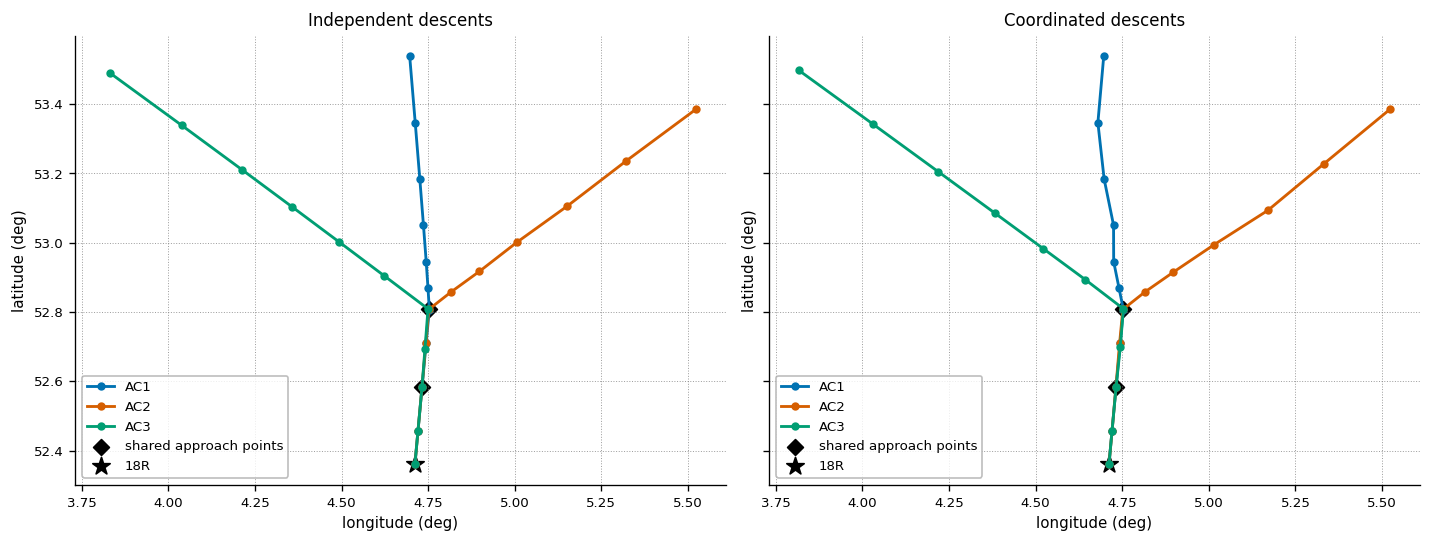

In [8]:
colors = dict(zip(result.trajectories, OKABE_ITO))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for axis, trajectories, title in (
    (axes[0], baseline, "Independent descents"),
    (axes[1], result.trajectories, "Coordinated descents"),
):
    for flight_id, trajectory in trajectories.items():
        axis.plot(
            trajectory.longitude,
            trajectory.latitude,
            marker="o",
            color=colors[flight_id],
            label=flight_id,
        )
    axis.scatter(
        [waypoint[1] for waypoint in APPROACH_WAYPOINTS],
        [waypoint[0] for waypoint in APPROACH_WAYPOINTS],
        marker="D",
        color="black",
        s=45,
        label="shared approach points",
    )
    axis.scatter(
        RUNWAY_18R[1], RUNWAY_18R[0], marker="*", color="black", s=120, label="18R"
    )
    axis.set(title=title, xlabel="longitude (deg)", ylabel="latitude (deg)")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(ls=":", alpha=0.7)
    axis.legend()
fig.tight_layout()
plt.show()

## Profiles and separation

The four panels separate the independent and coordinated results. The top row shows their altitude profiles; the bottom row shows every pair's high-order separation metric using display interpolation between returned trajectory nodes. Red shading identifies intervals below the required metric, making the independent conflicts and their coordinated removal directly comparable.

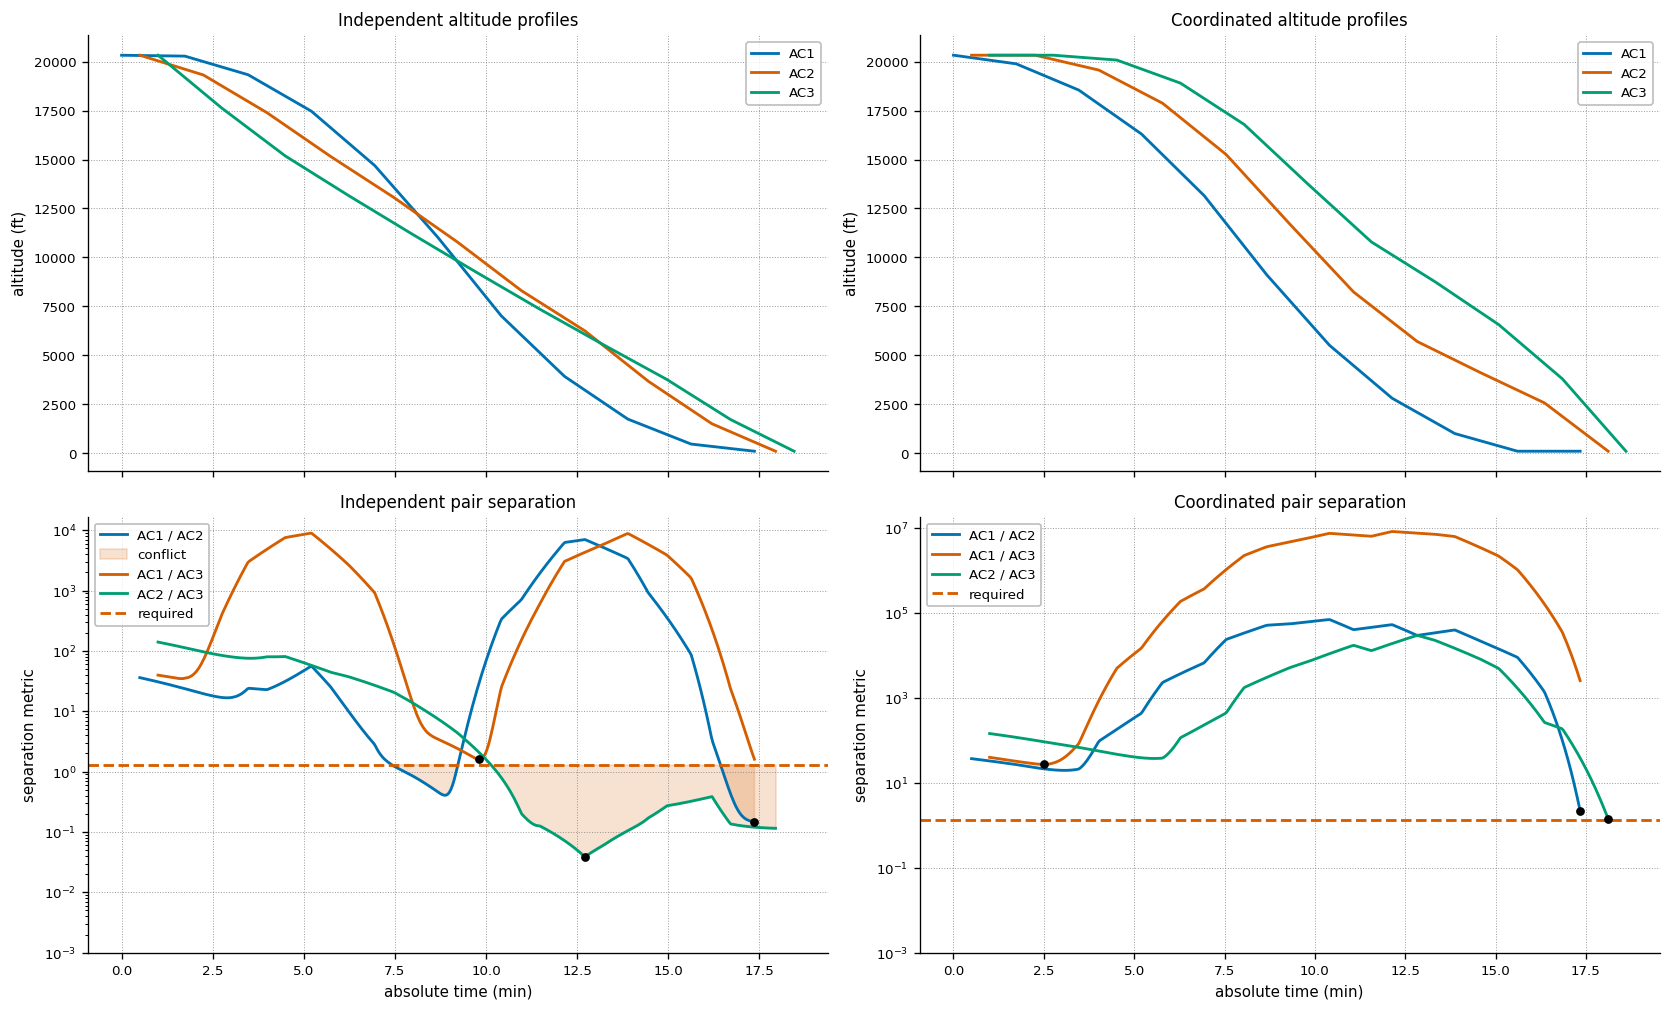

In [9]:
separation_proj = Proj(
    proj="aeqd", lat_0=RUNWAY_18R[0], lon_0=RUNWAY_18R[1], datum="WGS84"
)


def pair_metric(first, second, config, samples=400):
    start = max(first.absolute_ts.iloc[0], second.absolute_ts.iloc[0])
    end = min(first.absolute_ts.iloc[-1], second.absolute_ts.iloc[-1])
    times = np.linspace(start, end, samples)
    first_lon = np.interp(times, first.absolute_ts, first.longitude)
    first_lat = np.interp(times, first.absolute_ts, first.latitude)
    second_lon = np.interp(times, second.absolute_ts, second.longitude)
    second_lat = np.interp(times, second.absolute_ts, second.latitude)
    first_x, first_y = separation_proj(first_lon, first_lat)
    second_x, second_y = separation_proj(second_lon, second_lat)
    dx = first_x - second_x
    dy = first_y - second_y
    dz = np.interp(times, first.absolute_ts, first.h) - np.interp(
        times, second.absolute_ts, second.h
    )
    metric = (
        (dx / config.horizontal_m) ** 2
        + (dy / config.horizontal_m) ** 2
        + (dz / config.vertical_m) ** config.vertical_power
    )
    return times, metric


config = separation_config
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5), sharex="col")
independent_has_conflict = False
for column, (case_name, trajectories) in enumerate(
    (("Independent", baseline), ("Coordinated", result.trajectories))
):
    profile_ax = axes[0, column]
    separation_ax = axes[1, column]
    for flight_id, trajectory in trajectories.items():
        profile_ax.plot(
            trajectory.absolute_ts / 60.0,
            trajectory.altitude,
            color=colors[flight_id],
            label=flight_id,
        )

    conflict_label_added = False
    for first_id, second_id in combinations(trajectories, 2):
        times, metric = pair_metric(
            trajectories[first_id], trajectories[second_id], config
        )
        display_metric = np.maximum(metric, 1e-4)
        separation_ax.plot(
            times / 60.0, display_metric, label=f"{first_id} / {second_id}"
        )
        worst = int(np.argmin(metric))
        separation_ax.scatter(
            times[worst] / 60.0,
            display_metric[worst],
            color="black",
            s=18,
            zorder=3,
        )
        conflict = metric < config.minimum_metric
        if np.any(conflict):
            independent_has_conflict |= case_name == "Independent"
            separation_ax.fill_between(
                times / 60.0,
                display_metric,
                config.minimum_metric,
                where=conflict,
                color=OKABE_ITO[1],
                alpha=0.18,
                label="conflict" if not conflict_label_added else None,
            )
            conflict_label_added = True

    separation_ax.axhline(
        config.minimum_metric, color=OKABE_ITO[1], ls="--", label="required"
    )
    profile_ax.set(title=f"{case_name} altitude profiles", ylabel="altitude (ft)")
    separation_ax.set(
        title=f"{case_name} pair separation",
        xlabel="absolute time (min)",
        ylabel="separation metric",
        yscale="log",
        ylim=(1e-3, None),
    )
    for axis in (profile_ax, separation_ax):
        axis.grid(ls=":", alpha=0.7)
        axis.legend()

assert independent_has_conflict
fig.tight_layout()
plt.show()

## Landing timeline

The independent landing times cluster together. The coordinated result creates the runway sequence required by the airborne separation constraint, without a prescribed time gap.

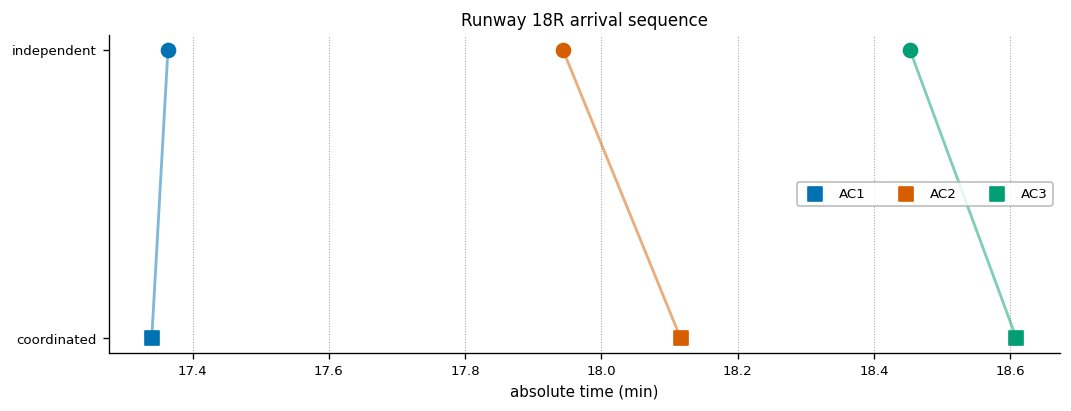

In [10]:
fig, axis = plt.subplots(figsize=(9, 3.5))
for index, flight_id in enumerate(result.trajectories):
    independent_time = baseline[flight_id].absolute_ts.iloc[-1] / 60.0
    coordinated_time = result.trajectories[flight_id].absolute_ts.iloc[-1] / 60.0
    axis.plot(
        [independent_time, coordinated_time],
        [1, 0],
        color=colors[flight_id],
        alpha=0.5,
    )
    axis.scatter(independent_time, 1, color=colors[flight_id], marker="o", s=70)
    axis.scatter(
        coordinated_time,
        0,
        color=colors[flight_id],
        marker="s",
        s=70,
        label=flight_id,
    )
axis.set(
    title="Runway 18R arrival sequence",
    xlabel="absolute time (min)",
    yticks=[0, 1],
    yticklabels=["coordinated", "independent"],
)
axis.grid(axis="x", ls=":", alpha=0.7)
axis.legend(ncol=3)
fig.tight_layout()
plt.show()

## Interpretation

The shared final-approach waypoints and runway endpoint make permanent spatial separation impossible: every aircraft eventually follows the same arrival path. Feasibility therefore comes from four-dimensional coordination, while the nonlinear optimizer adjusts continuous descent trajectories and times to minimize fuel. For larger traffic sets, runway scheduling and rolling-horizon decomposition should sit above these small joint solves.